In [3]:
# Import Libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

from google.colab import files
import pandas as pd

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

Saving Dataset (CEAS_08).csv to Dataset (CEAS_08).csv


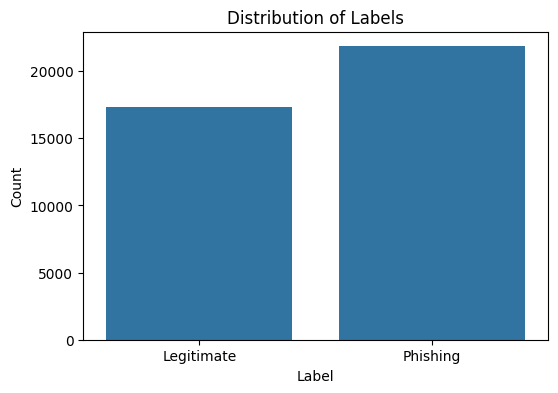

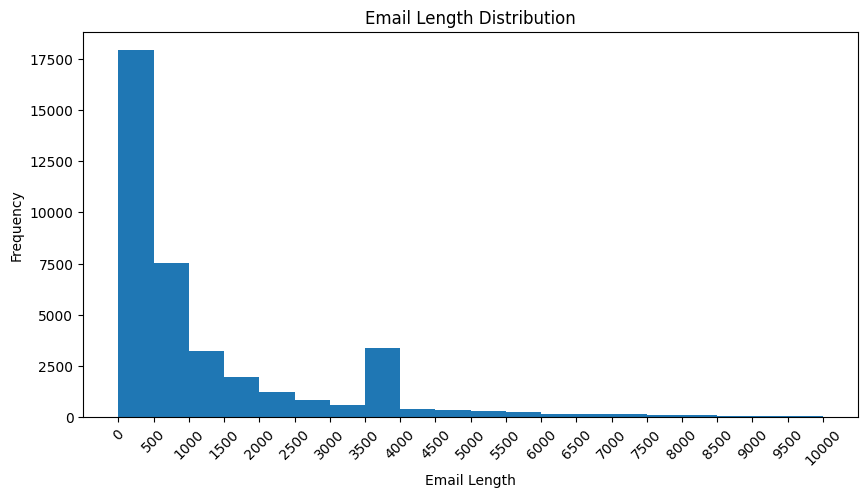

Maximum email body length: 143996
Minimum email body length: 14
Average email body length: 1571.0798130459211


In [4]:
# Visualisasi EDA Awal


df = df[['body', 'label']].copy()
df['body'] = df['body'].astype(str)
df['body_length'] = df['body'].apply(len)

# Visualisasi 1 (Barchart)

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Distribution of Labels')
plt.xticks([0,1], ['Legitimate', 'Phishing'])  # Legend 0 = Legitimate, 1 = Phishing
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()
print("")

# Visualisasi 2 (Histrogram)

plt.figure(figsize=(10,5))

# bins per 500 dari 0 sampai 10.000
bins = np.arange(0, 10000 + 500, 500)

plt.hist(df['body_length'], bins=bins, range=(0,10000))
plt.title("Email Length Distribution")
plt.xlabel("Email Length")
plt.ylabel("Frequency")

# x-axis tampil per 500
plt.xticks(np.arange(0, 10000 + 500, 500), rotation=45)

plt.show()

print("Maximum email body length:", df['body_length'].max())
print("Minimum email body length:", df['body_length'].min())
print("Average email body length:", df['body_length'].mean())

In [5]:
# ===================================================
# Step 4: Train-Test Split + SMOTE
# ===================================================
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer

# Target
y = df['label']  # 0 = Legitimate, 1 = Phishing

# Fitur: TF-IDF dari 'body'
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df['body'])

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Terapkan SMOTE di training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Cek ukuran dataset
print("Original training set:", X_train.shape, y_train.shape)
print("Resampled training set:", X_train_res.shape, y_train_res.shape)
print("Testing set:", X_test.shape, y_test.shape)

Original training set: (31323, 5000) (31323,)
Resampled training set: (34946, 5000) (34946,)
Testing set: (7831, 5000) (7831,)


SVM selesai dilatih dan dievaluasi.
Random Forest selesai dilatih dan dievaluasi.
Naive Bayes selesai dilatih dan dievaluasi.
Logistic Regression selesai dilatih dan dievaluasi.
Decision Tree selesai dilatih dan dievaluasi.
=== Performance Comparison ===


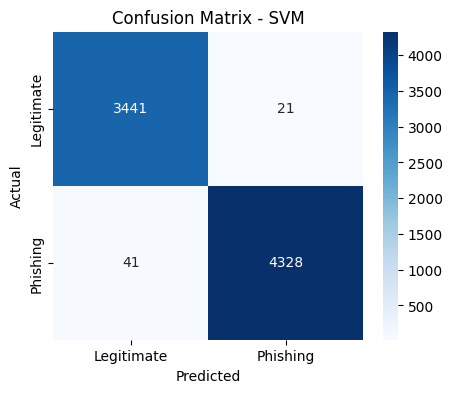

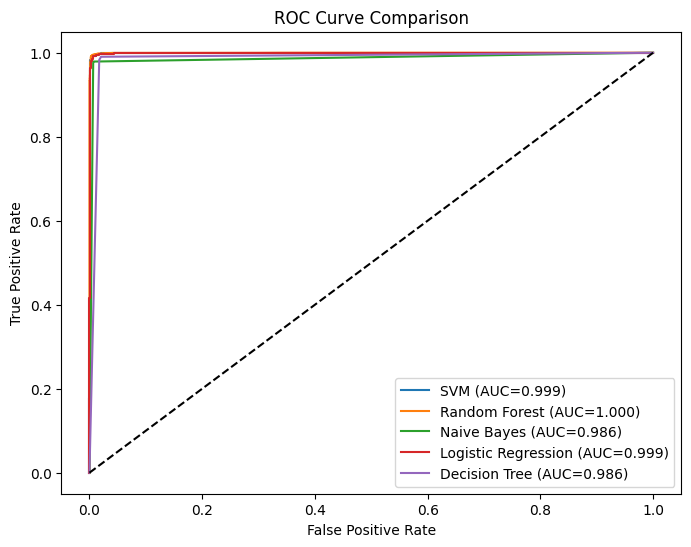

In [ ]:
# Model Training & Evaluation

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "SVM": SVC(kernel='linear', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Training

results = []

for name, model in models.items():
    # Training
    if name == "Naive Bayes":  # GaussianNB tidak support sparse matrix
        model.fit(X_train_res.toarray(), y_train_res)
        y_pred = model.predict(X_test.toarray())
        y_prob = model.predict_proba(X_test.toarray())[:,1]
    else:
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

    # Evaluasi
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": roc
    })

    print(f"{name} selesai dilatih dan dievaluasi.")

# Hasil
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print("=== Performance Comparison ===")
results_df

# ROC Curve

plt.figure(figsize=(8,6))
for name, model in models.items():
    if name == "Naive Bayes":
        y_prob = model.predict_proba(X_test.toarray())[:,1]
    else:
        y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

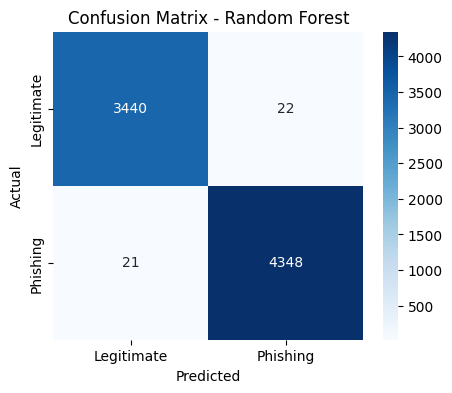

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Pilih model terbaik
best_model = models['Random Forest']

# Prediksi pada X_test
y_pred = best_model.predict(X_test)

# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi dengan seaborn
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legitimate","Phishing"],
            yticklabels=["Legitimate","Phishing"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
# ===================================================
# Step 6: Performance Summary Table
# ===================================================

# Gunakan results_df dari Step 5
# Tampilkan tabel rangkuman model
print("=== Performance Summary of All Models ===")
results_df

=== Performance Summary of All Models ===


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Random Forest,0.994509,0.994966,0.995193,0.995080,0.999720
0,SVM,0.992083,0.995171,0.990616,0.992888,0.999425
3,Logistic Regression,0.992083,0.994262,0.991531,0.992895,0.999313
4,Decision Tree,0.985570,0.983856,0.990387,0.987111,0.986438
2,Naive Bayes,0.985187,0.994650,0.978714,0.986617,0.986146
